# FCOS ResNet Object Detector

Trains `FCOSObjectDetectorResNet` with a 28x28 / 14x14 FPN, decoupled towers, centerness gating, and per-pixel ltrb distances.

**Pipeline:**
`get_detection_loaders(fcos=True)` -> `get_fcos_detector('s')` -> `FCOSLoss` -> `fit()`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch

from utils.dataset import get_detection_loaders
from utils.fcos_targets import FCOSTargets, FCOSTargetGenerator
from generator.dataset import EMNIST_CLASS_NAMES
from utils.trainer import fit, evaluate_detection
from utils.visualizer import Visualizer
from utils.callbacks import ModelCheckpoint
from utils.losses import FCOSLoss
from models import get_fcos_detector

# ── Config ────────────────────────────────────────────────────────────────────
SEED                = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE              = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT_DIR            = '../data'
BATCH_SIZE          = 198
EPOCHS              = 60
VALIDATION_INTERVAL = 5
GRID_SIZES          = (28, 14)
CONF_THRESH         = 0.5
MODEL_SIZE          = 'm'
GPU_TARGETS         = False
CLASS_NAMES         = EMNIST_CLASS_NAMES['bymerge']


def flatten_detection_grids(grids):
    """Flatten one- or multi-scale prediction/target grids to (B, N, D)."""
    if isinstance(grids, dict):
        return torch.cat(
            [grid.reshape(grid.size(0), -1, grid.size(-1)) for grid in grids.values()],
            dim=1,
        )
    return grids.reshape(grids.size(0), -1, grids.size(-1))


print(f'Device      : {DEVICE}')
print(f'PyTorch     : {torch.__version__}')
print(f'Grid sizes  : {GRID_SIZES}')
print(f'Epochs      : {EPOCHS}')
print(f'Validation interval: every {VALIDATION_INTERVAL} epochs plus final')
print(f'FCOS targets: {"CUDA" if GPU_TARGETS else "CPU workers"}')


Device      : cuda
PyTorch     : 2.11.0+cu130
Grid sizes  : (28, 14)
Epochs      : 60
Validation interval: every 5 epochs plus final
FCOS targets: CPU workers


## 1 · Data Loaders


In [2]:
train_loader, val_loader, test_loader = get_detection_loaders(
    batch_size=BATCH_SIZE,
    test=True,
    grid_sizes=GRID_SIZES,
    fcos=True,
    defer_fcos_targets=GPU_TARGETS,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
imgs, targets, annotations = next(iter(train_loader))
if targets is None:
    boxes_smoke, labels_smoke = annotations
    targets = FCOSTargetGenerator(grid_sizes=GRID_SIZES).generate_targets(
        boxes_smoke,
        labels_smoke,
        device=torch.device('cpu'),
    )
    print('FCOS targets deferred to the training device; CPU smoke target generated.')

print(f'Image batch shape: {imgs.shape}')
assert isinstance(targets, FCOSTargets)
assert all(torch.all(reg >= 0) for reg in targets.reg_targets.values())
assert all(torch.all((cent >= 0) & (cent <= 1)) for cent in targets.centerness_targets.values())
for grid_size in GRID_SIZES:
    print(
        f'P{grid_size}: cls={targets.cls_targets[grid_size].shape} | '
        f'reg={targets.reg_targets[grid_size].shape} | '
        f'cent={targets.centerness_targets[grid_size].shape}'
    )
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Image batch shape: torch.Size([198, 1, 224, 224])
P28: cls=torch.Size([198, 28, 28]) | reg=torch.Size([198, 28, 28, 4]) | cent=torch.Size([198, 28, 28])
P14: cls=torch.Size([198, 14, 14]) | reg=torch.Size([198, 14, 14, 4]) | cent=torch.Size([198, 14, 14])
Train batches: 1213 | Val batches: 76


## 2 · Model Architecture


In [3]:
model = get_fcos_detector(size=MODEL_SIZE).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Forward smoke-test ────────────────────────────────────────────────────────
with torch.no_grad():
    outputs_by_scale = model(imgs.to(DEVICE))

for grid_size in GRID_SIZES:
    outputs = outputs_by_scale[grid_size]
    print(
        f'P{grid_size}: cls={outputs["cls_logits"].shape} | '
        f'reg={outputs["reg_ltrb"].shape} | '
        f'cent={outputs["centerness_logits"].shape}'
    )

Parameters: 7,143,606
P28: cls=torch.Size([198, 28, 28, 47]) | reg=torch.Size([198, 28, 28, 4]) | cent=torch.Size([198, 28, 28])
P14: cls=torch.Size([198, 14, 14, 47]) | reg=torch.Size([198, 14, 14, 4]) | cent=torch.Size([198, 14, 14])


## 3 · Loss Function, Optimiser & Scheduler


In [4]:
criterion = FCOSLoss(
    lambda_reg=1.0,
    lambda_centerness=1.0,
    focal_alpha=0.25,
    focal_gamma=2.0,
    grid_sizes=GRID_SIZES,
)

# Complete FCOS smoke check: loss and backward pass.
smoke_preds = model(imgs[:2].to(DEVICE))
smoke_targets = FCOSTargets(
    cls_targets={k: v[:2] for k, v in targets.cls_targets.items()},
    reg_targets={k: v[:2] for k, v in targets.reg_targets.items()},
    centerness_targets={k: v[:2] for k, v in targets.centerness_targets.items()},
).to(DEVICE)
smoke_loss, smoke_parts = criterion(smoke_preds, smoke_targets)
smoke_loss.backward()
model.zero_grad(set_to_none=True)
print(f'Smoke loss: {smoke_parts}')

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
)

scale_tag = 'x'.join(map(str, GRID_SIZES))
NAME = f'fcos_{MODEL_SIZE}_{scale_tag}'
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f'../checkpoint/{NAME}_latest.pth',
    best_model_path=f'../checkpoint/{NAME}_best.pth',
    mode='max',
)

# fit() uses BF16 autocast on CUDA; GradScaler is intentionally omitted.
scaler = None

print(f'Criterion : {type(criterion).__name__}')
print(f'Optimizer : {type(optimizer).__name__}')
print(f'Scheduler : {type(scheduler).__name__}')
print(f'Run name  : {NAME}')

Smoke loss: {'loss': 2.0231215953826904, 'cls_loss': 1.1114033460617065, 'reg_loss': 0.2329140603542328, 'cent_loss': 0.6788040995597839, 'num_pos': 94.0}
Criterion : FCOSLoss
Optimizer : AdamW
Scheduler : OneCycleLR
Run name  : fcos_m_28x14


## 4 · Training


In [5]:
history, logger = fit(
    model       = model,
    trainloader = train_loader,
    valloader   = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    device      = DEVICE,
    epochs      = EPOCHS,
    scheduler   = scheduler,
    scaler      = scaler,
    checkpoint  = checkpoint,
    step_scheduler_per_batch = True,
    validation_interval = VALIDATION_INTERVAL,
    verbose     = True,
    log         = True,
    model_label = NAME,
    resume      = True,
)


Training with bf16 autocast | Epochs: 60
[RunLogger] ▶  Run 'fcos_m_28x14_20260920_112213' started — saving to 'C:\OD-From-Scratch\logs\FCOSObjectDetectorResNet\fcos_m_28x14_20260920_112213.json'
Could not resume training: No checkpoint found at '..\checkpoint\fcos_m_28x14_latest.pth'. Cannot resume training.
Batch  1 | data=835.5ms pad=20.2ms forward=344.5ms loss=10.8ms backward=306.3ms step=194.9ms
Batch  2 | data=0.4ms pad=9.5ms forward=44.4ms loss=6.5ms backward=95.8ms step=1.8ms
Batch  3 | data=0.4ms pad=9.9ms forward=44.6ms loss=6.9ms backward=94.3ms step=2.6ms
Batch  4 | data=0.5ms pad=8.4ms forward=44.4ms loss=7.4ms backward=95.3ms step=2.1ms
Batch  5 | data=0.7ms pad=8.5ms forward=44.5ms loss=8.0ms backward=94.6ms step=2.5ms
Train: 196.4s | Val: 68.2s
  --> Det  | PR: 0.999 | Rec: 0.744 | F1: 0.853 | TP: 89269 FP: 133 FN: 30636
  --> Cls  | Acc: 0.879
  --> E2E  | F1: 0.750 | PR: 0.878 | Rec: 0.654
[RunLogger] Epoch   1 | train_loss=0.9973  val_loss=0.7674  val_f1=0.7498%  lr=

## 5 · Training Dashboard & Curves


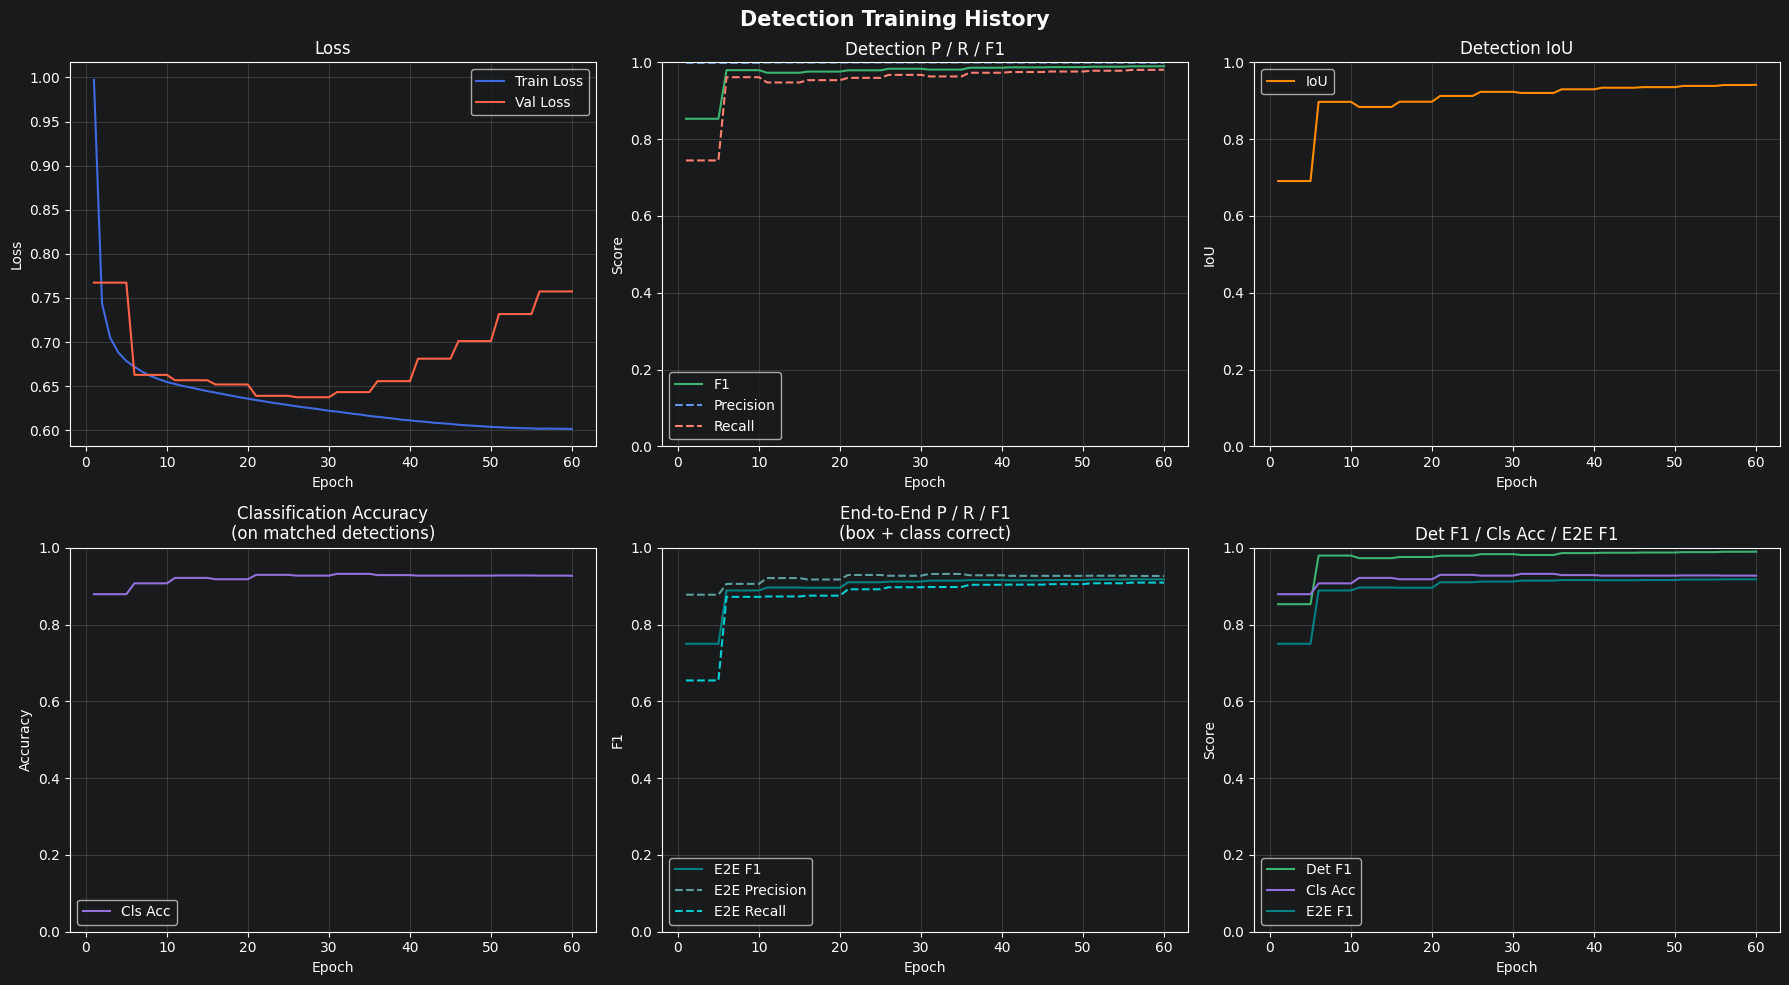

In [6]:
# Full detection training dashboard (Loss, Det P/R/F1, IoU, Cls Acc, E2E P/R/F1)
Visualizer.visualize_detection_history(history)


## 6 · Final Evaluation on Test Set


In [7]:
# Load best checkpoint weights if checkpoint callback was used
if 'checkpoint' in locals() and checkpoint is not None:
    checkpoint.restore_best_weights()

metrics = evaluate_detection(model, test_loader, criterion, DEVICE, conf_threshold=CONF_THRESH)

det = metrics['detection']
cls = metrics['classification']
e2e = metrics['end_to_end']

print('=== Detection (localisation) ===')
print(f"  Loss     : {metrics['loss']:.4f}")
print(f"  IoU      : {det['iou']:.4f}")
print(f"  Precision: {det['precision']:.4f}")
print(f"  Recall   : {det['recall']:.4f}")
print(f"  F1       : {det['f1']:.4f}")
print(f"  TP/FP/FN : {det['tp']} / {det['fp']} / {det['fn']}")

print('\n=== Classification (on matched detections) ===')
print(f"  Accuracy : {cls['accuracy']:.4f}")
print('  Per-class:')
for k, v in cls['per_class'].items():
    name = v.get('name', f'class_{k}')
    print(f"    [{k}] {name}: acc={v['accuracy']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}  e2e_f1={v['e2e_f1']:.4f}")

print('\n=== End-to-End (box + class correct) ===')
print(f"  Precision: {e2e['precision']:.4f}")
print(f"  Recall   : {e2e['recall']:.4f}")
print(f"  F1       : {e2e['f1']:.4f}")
print(f"  TP/FP/FN : {e2e['tp']} / {e2e['fp']} / {e2e['fn']}")


=== Detection (localisation) ===
  Loss     : 0.8561
  IoU      : 0.9386
  Precision: 0.9988
  Recall   : 0.9782
  F1       : 0.9884
  TP/FP/FN : 352716 / 421 / 7851

=== Classification (on matched detections) ===
  Accuracy : 0.9056
  Per-class:
    [0] 0: acc=0.6514  e2e_p=0.6215  e2e_r=0.6459  e2e_f1=0.6335
    [1] 1: acc=0.6403  e2e_p=0.5647  e2e_r=0.4405  e2e_f1=0.4949
    [2] 2: acc=0.9174  e2e_p=0.9323  e2e_r=0.9130  e2e_f1=0.9226
    [3] 3: acc=0.9938  e2e_p=0.9864  e2e_r=0.9925  e2e_f1=0.9894
    [4] 4: acc=0.9622  e2e_p=0.9579  e2e_r=0.9576  e2e_f1=0.9578
    [5] 5: acc=0.9229  e2e_p=0.9446  e2e_r=0.9191  e2e_f1=0.9316
    [6] 6: acc=0.9518  e2e_p=0.9416  e2e_r=0.9476  e2e_f1=0.9446
    [7] 7: acc=0.9889  e2e_p=0.9738  e2e_r=0.9845  e2e_f1=0.9791
    [8] 8: acc=0.9820  e2e_p=0.9592  e2e_r=0.9753  e2e_f1=0.9672
    [9] 9: acc=0.8032  e2e_p=0.6654  e2e_r=0.7885  e2e_f1=0.7217
    [10] A: acc=0.9883  e2e_p=0.9576  e2e_r=0.9850  e2e_f1=0.9711
    [11] B: acc=0.9809  e2e_p=0.9706 

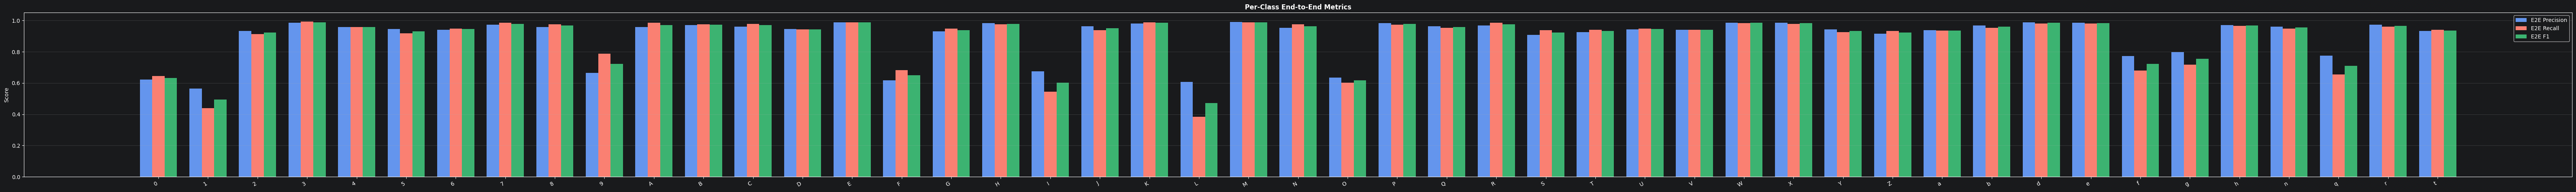

In [8]:
Visualizer.visualize_per_class_e2e(metrics)

## 7 · Prediction Visualisation

The FCOS prediction path decodes ltrb distances, applies centerness-gated scores, and uses class-wise batched NMS at IoU 0.45.

Visualisation batch: 198 images
First image detections after centerness-NMS: 4
First image boxes shape: torch.Size([4, 4])


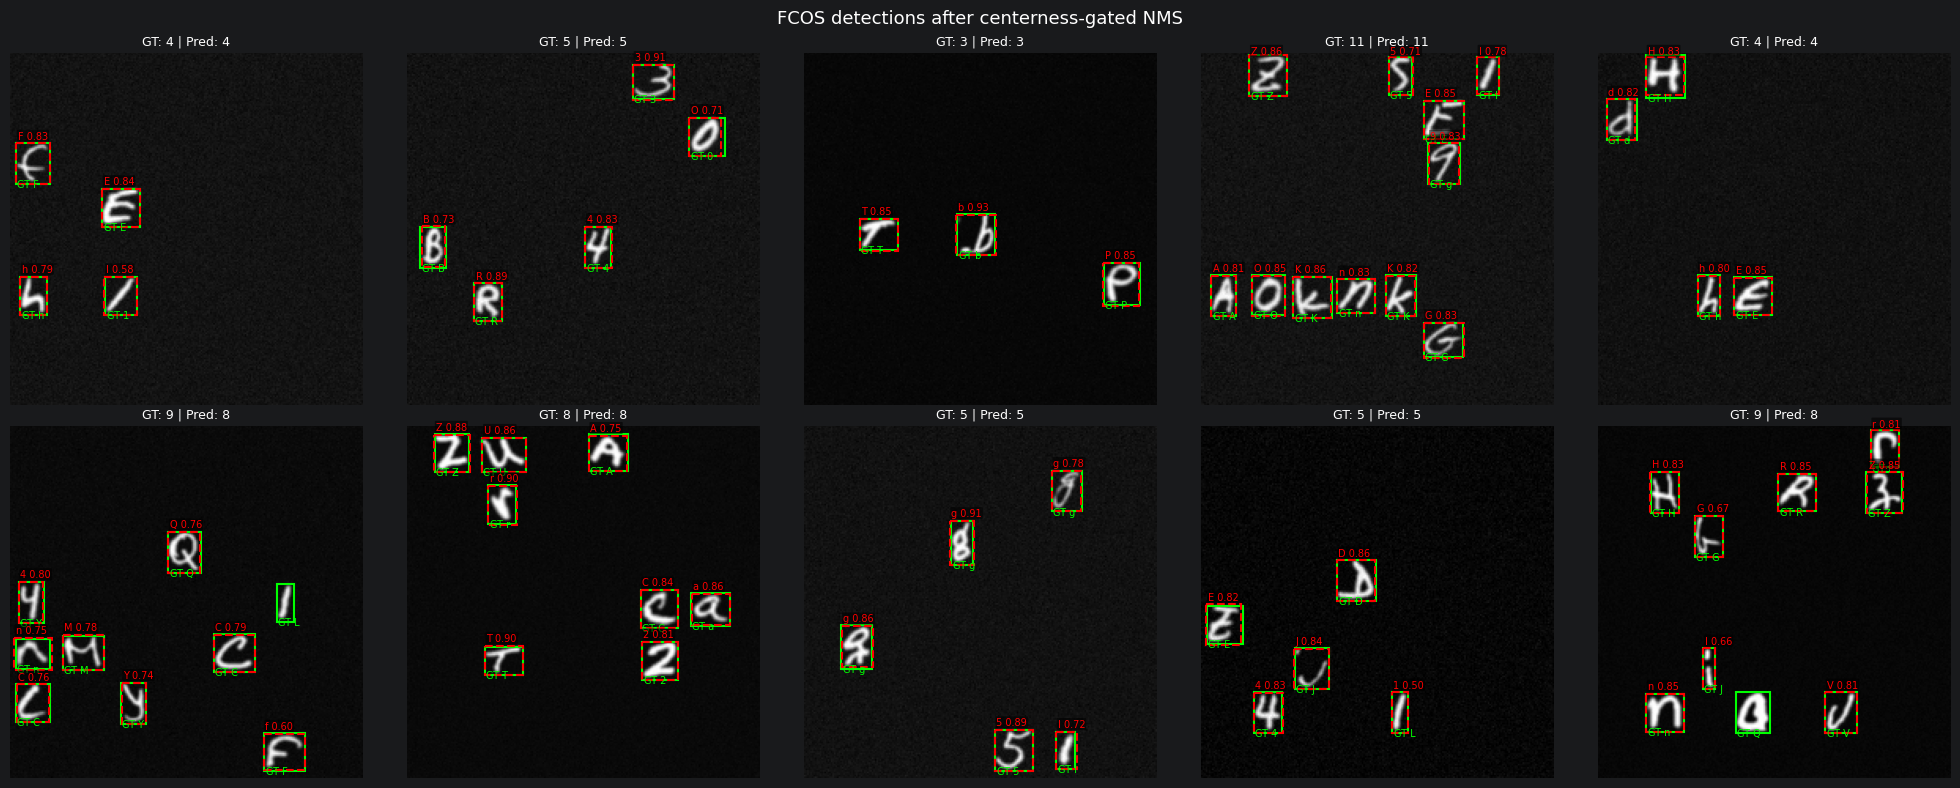

In [9]:
from utils.pipeline import _decode_fcos_candidates

imgs_t, targets_t, annotations_t = next(iter(test_loader))
with torch.no_grad():
    preds_t = model(imgs_t.to(DEVICE))
    candidates_t = _decode_fcos_candidates(
        model, preds_t, CONF_THRESH, iou_threshold=0.45
    )

gt_boxes_t, gt_labels_t = annotations_t
print(f'Visualisation batch: {imgs_t.shape[0]} images')
print(f'First image detections after centerness-NMS: {candidates_t[0][0].shape[0]}')
print(f'First image boxes shape: {candidates_t[0][0].shape}')

Visualizer.visualize_fcos_batch(
    imgs_t,
    candidates_t,
    gt_boxes=gt_boxes_t,
    gt_labels=gt_labels_t,
    class_names=CLASS_NAMES,
    max_images=10,
)

## 8 · Confidence Threshold Sweep

Sweeps confidence thresholds on the held-out **test set** to evaluate the full Precision / Recall / F1 trade-off.


In [10]:
sweep_results = []
for threshold in np.arange(0.1, 0.95, 0.1):
    threshold_metrics = evaluate_detection(
        model, test_loader, criterion, DEVICE,
        conf_threshold=float(threshold), iou_threshold=0.5,
    )
    det = threshold_metrics['detection']
    per_class = threshold_metrics['classification']['per_class']
    sweep_results.append({
        'conf': round(float(threshold), 2),
        'precision': round(det['precision'], 4),
        'recall': round(det['recall'], 4),
        'f1': round(det['f1'], 4),
        'tp': det['tp'],
        'fp': det['fp'],
        'fn': det['fn'],
        'cls_accuracy': round(threshold_metrics['classification']['accuracy'], 4),
        'per_class_e2e': {
            int(class_id): {
                'precision': values['e2e_precision'],
                'recall': values['e2e_recall'],
                'f1': values['e2e_f1'],
            }
            for class_id, values in per_class.items()
        },
    })

print(sweep_results)


[{'conf': 0.1, 'precision': 0.9563, 'recall': 0.9999, 'f1': 0.9776, 'tp': 360543, 'fp': 16465, 'fn': 24, 'cls_accuracy': 0.8953, 'per_class_e2e': {0: {'precision': 0.5701, 'recall': 0.6489, 'f1': 0.607}, 1: {'precision': 0.336, 'recall': 0.6124, 'f1': 0.4339}, 2: {'precision': 0.9125, 'recall': 0.9149, 'f1': 0.9137}, 3: {'precision': 0.9729, 'recall': 0.9932, 'f1': 0.9829}, 4: {'precision': 0.937, 'recall': 0.96, 'f1': 0.9483}, 5: {'precision': 0.9217, 'recall': 0.9206, 'f1': 0.9211}, 6: {'precision': 0.9116, 'recall': 0.9492, 'f1': 0.93}, 7: {'precision': 0.9509, 'recall': 0.9862, 'f1': 0.9682}, 8: {'precision': 0.9446, 'recall': 0.9788, 'f1': 0.9614}, 9: {'precision': 0.6188, 'recall': 0.7973, 'f1': 0.6968}, 10: {'precision': 0.9376, 'recall': 0.9865, 'f1': 0.9614}, 11: {'precision': 0.9578, 'recall': 0.9785, 'f1': 0.968}, 12: {'precision': 0.9339, 'recall': 0.9805, 'f1': 0.9566}, 13: {'precision': 0.9161, 'recall': 0.9462, 'f1': 0.9309}, 14: {'precision': 0.9759, 'recall': 0.9898, '

Best FCOS confidence threshold: 0.40 | Det F1: 0.9946


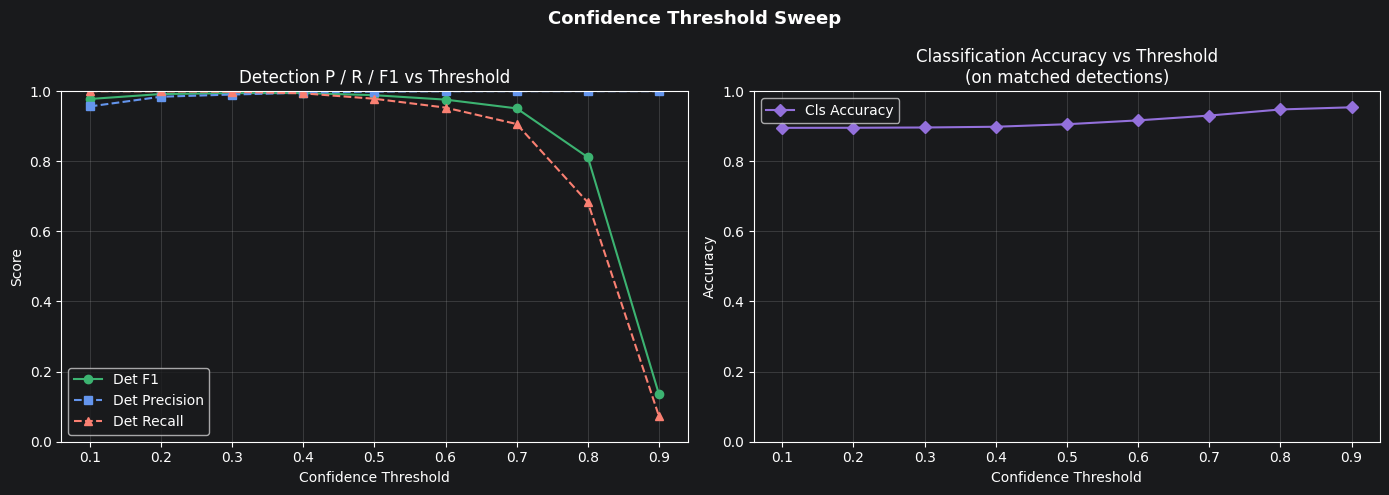

In [11]:
best_r = max(sweep_results, key=lambda r: r['f1'])
print(f"Best FCOS confidence threshold: {best_r['conf']:.2f} | Det F1: {best_r['f1']:.4f}")
Visualizer.visualize_sweep_results(sweep_results)
